### Agent Skiils Usage and Demonstration

#### 1. Without Skills or context in the prompt

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

model = ChatOpenAI(model="gpt-5-mini")

/Users/aritrasen/Documents/code/agents_observability/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Agent without context

In [13]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# Create the agent without skills or proper context in the system prompt
agent = create_agent(
    model,
    system_prompt=(
        "You are a SQL query assistant that helps users "
        "write queries against business databases."
    ),
    checkpointer=InMemorySaver(),
)

In [4]:
import uuid

# Configuration for this conversation thread
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

# Ask for a SQL query
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Write a SQL query to find all customers "
                    "who made orders over $1000 in the last month"
                ),
            }
        ]
    },
    config
)

# Print the conversation
for message in result["messages"]:
    if hasattr(message, 'pretty_print'):
        message.pretty_print()
    else:
        print(f"{message.type}: {message.content}")

================================ Human Message =================================

Write a SQL query to find all customers who made orders over $1000 in the last month
================================== Ai Message ==================================

I can help — a couple of quick clarifying questions:
- Do you mean "last month" as the previous calendar month (e.g., if today is 2026-03-28 then last month = 2026-02-01..2026-02-28) or the last N days (e.g., last 30 days)?
- Which SQL dialect (Postgres, MySQL, SQL Server, etc.) and what are your table/column names? (Common assumptions below: customers(id,...), orders(id, customer_id, total_amount, order_date).)

Below are common variants you can copy & adapt.

1) Postgres — sliding last 30 days (inclusive)
SELECT DISTINCT c.*
FROM customers c
JOIN orders o ON o.customer_id = c.id
WHERE o.total_amount > 1000
  AND o.order_date >= current_date - INTERVAL '30 days';

2) Postgres — previous calendar month
SELECT DISTINCT c.*
FROM customers c
JO

Issues:

- No schema/business rules in system prompt (agent baseline just “SQL query assistant”), so it can’t enforce domain-specific constraints (e.g., only `completed` orders).
- No database “last month” definition; agent supplies two interpretations rather than a single clear answer.
- Risk of inconsistent filtering: may include non-completed orders, inactive customers, or cancelled/refunded data if not explicitly told.
- Missing explicit mention of table joins/primary keys from schema (relies on guesswork).

#### 2. Proper context in the system prompt

Context with:
-  Description about the schema
-  Table definations of multiple schemas
-  Column details about the tables
-  Business logic 
-  Example query

In [5]:
context = """ We two databases mainly named:
    1. Sales analytics
    2. Inventory management

    Below are the details of this two databases:

    1. Sales analytics:

    Description: Database schema and business logic for sales data analysis including customers, orders, and revenue.

    # Sales Analytics Schema

    ## Tables

    ### customers
    - customer_id (PRIMARY KEY)
    - name
    - email
    - signup_date
    - status (active/inactive)
    - customer_tier (bronze/silver/gold/platinum)

    ### orders
    - order_id (PRIMARY KEY)
    - customer_id (FOREIGN KEY -> customers)
    - order_date
    - status (pending/completed/cancelled/refunded)
    - total_amount
    - sales_region (north/south/east/west)

    ### order_items
    - item_id (PRIMARY KEY)
    - order_id (FOREIGN KEY -> orders)
    - product_id
    - quantity
    - unit_price
    - discount_percent

    ## Business Logic

    **Active customers**: status = 'active' AND signup_date <= CURRENT_DATE - INTERVAL '90 days'

    **Revenue calculation**: Only count orders with status = 'completed'. Use total_amount from orders table, which already accounts for discounts.

    **Customer lifetime value (CLV)**: Sum of all completed order amounts for a customer.

    **High-value orders**: Orders with total_amount > 1000

    ## Example Query

    -- Get top 10 customers by revenue in the last quarter
    SELECT
        c.customer_id,
        c.name,
        c.customer_tier,
        SUM(o.total_amount) as total_revenue
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    WHERE o.status = 'completed'
    AND o.order_date >= CURRENT_DATE - INTERVAL '3 months'
    GROUP BY c.customer_id, c.name, c.customer_tier
    ORDER BY total_revenue DESC
    LIMIT 10;

    2. Inventory management: 

    Description: Database schema and business logic for inventory tracking including products, warehouses, and stock levels.


    # Inventory Management Schema

    ## Tables

    ### products
    - product_id (PRIMARY KEY)
    - product_name
    - sku
    - category
    - unit_cost
    - reorder_point (minimum stock level before reordering)
    - discontinued (boolean)

    ### warehouses
    - warehouse_id (PRIMARY KEY)
    - warehouse_name
    - location
    - capacity

    ### inventory
    - inventory_id (PRIMARY KEY)
    - product_id (FOREIGN KEY -> products)
    - warehouse_id (FOREIGN KEY -> warehouses)
    - quantity_on_hand
    - last_updated

    ### stock_movements
    - movement_id (PRIMARY KEY)
    - product_id (FOREIGN KEY -> products)
    - warehouse_id (FOREIGN KEY -> warehouses)
    - movement_type (inbound/outbound/transfer/adjustment)
    - quantity (positive for inbound, negative for outbound)
    - movement_date
    - reference_number

    ## Business Logic

    **Available stock**: quantity_on_hand from inventory table where quantity_on_hand > 0

    **Products needing reorder**: Products where total quantity_on_hand across all warehouses is less than or equal to the product's reorder_point

    **Active products only**: Exclude products where discontinued = true unless specifically analyzing discontinued items

    **Stock valuation**: quantity_on_hand * unit_cost for each product

    ## Example Query

    -- Find products below reorder point across all warehouses
    SELECT
        p.product_id,
        p.product_name,
        p.reorder_point,
        SUM(i.quantity_on_hand) as total_stock,
        p.unit_cost,
        (p.reorder_point - SUM(i.quantity_on_hand)) as units_to_reorder
    FROM products p
    JOIN inventory i ON p.product_id = i.product_id
    WHERE p.discontinued = false
    GROUP BY p.product_id, p.product_name, p.reorder_point, p.unit_cost
    HAVING SUM(i.quantity_on_hand) <= p.reorder_point
    ORDER BY units_to_reorder DESC;
"""

In [8]:
system_promot_with_context = (
        "You are a SQL query assistant that helps users "
        "write queries against business databases."
        "The user will ask you to write SQL queries based on the context provided below. "
        "Use the context to understand the database schema and business logic, and write accurate SQL queries based on the user's request. "
        "Context: " + context
    )

print(system_promot_with_context)

You are a SQL query assistant that helps users write queries against business databases.The user will ask you to write SQL queries based on the context provided below. Use the context to understand the database schema and business logic, and write accurate SQL queries based on the user's request. Context:  We two databases mainly named:
    1. Sales analytics
    2. Inventory management

    Below are the details of this two databases:

    1. Sales analytics:

    Description: Database schema and business logic for sales data analysis including customers, orders, and revenue.

    # Sales Analytics Schema

    ## Tables

    ### customers
    - customer_id (PRIMARY KEY)
    - name
    - email
    - signup_date
    - status (active/inactive)
    - customer_tier (bronze/silver/gold/platinum)

    ### orders
    - order_id (PRIMARY KEY)
    - customer_id (FOREIGN KEY -> customers)
    - order_date
    - status (pending/completed/cancelled/refunded)
    - total_amount
    - sales_region (

In [9]:
agent = create_agent(
    model,
    system_prompt=system_promot_with_context,
    checkpointer=InMemorySaver(),
)

# Configuration for this conversation thread
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

# Ask for a SQL query
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Write a SQL query to find all customers "
                    "who made orders over $1000 in the last month"
                ),
            }
        ]
    },
    config
)

# Print the conversation
for message in result["messages"]:
    if hasattr(message, 'pretty_print'):
        message.pretty_print()
    else:
        print(f"{message.type}: {message.content}")

================================ Human Message =================================

Write a SQL query to find all customers who made orders over $1000 in the last month
================================== Ai Message ==================================

Here are a couple of safe options (Postgres-style) depending on how you define "last month".

1) Previous calendar month (e.g., if today is 2026-03-28 this returns orders from 2026-02-01 through 2026-02-28):
SELECT DISTINCT
    c.customer_id,
    c.name,
    c.email,
    c.customer_tier
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.status = 'completed'
  AND o.total_amount > 1000
  AND o.order_date >= DATE_TRUNC('month', CURRENT_DATE) - INTERVAL '1 month'
  AND o.order_date < DATE_TRUNC('month', CURRENT_DATE');

2) Last 30 days (rolling window):
SELECT DISTINCT
    c.customer_id,
    c.name,
    c.email,
    c.customer_tier
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.status = 'completed'


Issues: 

Attention Degradation: LLMs often ignore or forget critical instructions and tool nuances when they are buried within a massive, single-block system prompt.

Context Window Starvation: Loading all context upfront consumes valuable token space, leaving less room for conversation history.

Increased Latency and Cost: Re-processing a massive, static prompt on every single conversational turn dramatically increases API costs and slows down response times.

Not Scalable approach : If there is an addition of new schema , context size will increase everytime this is not a scalable solution.

### 3. Finally : Agent with SKILL.md files for each DB Schema

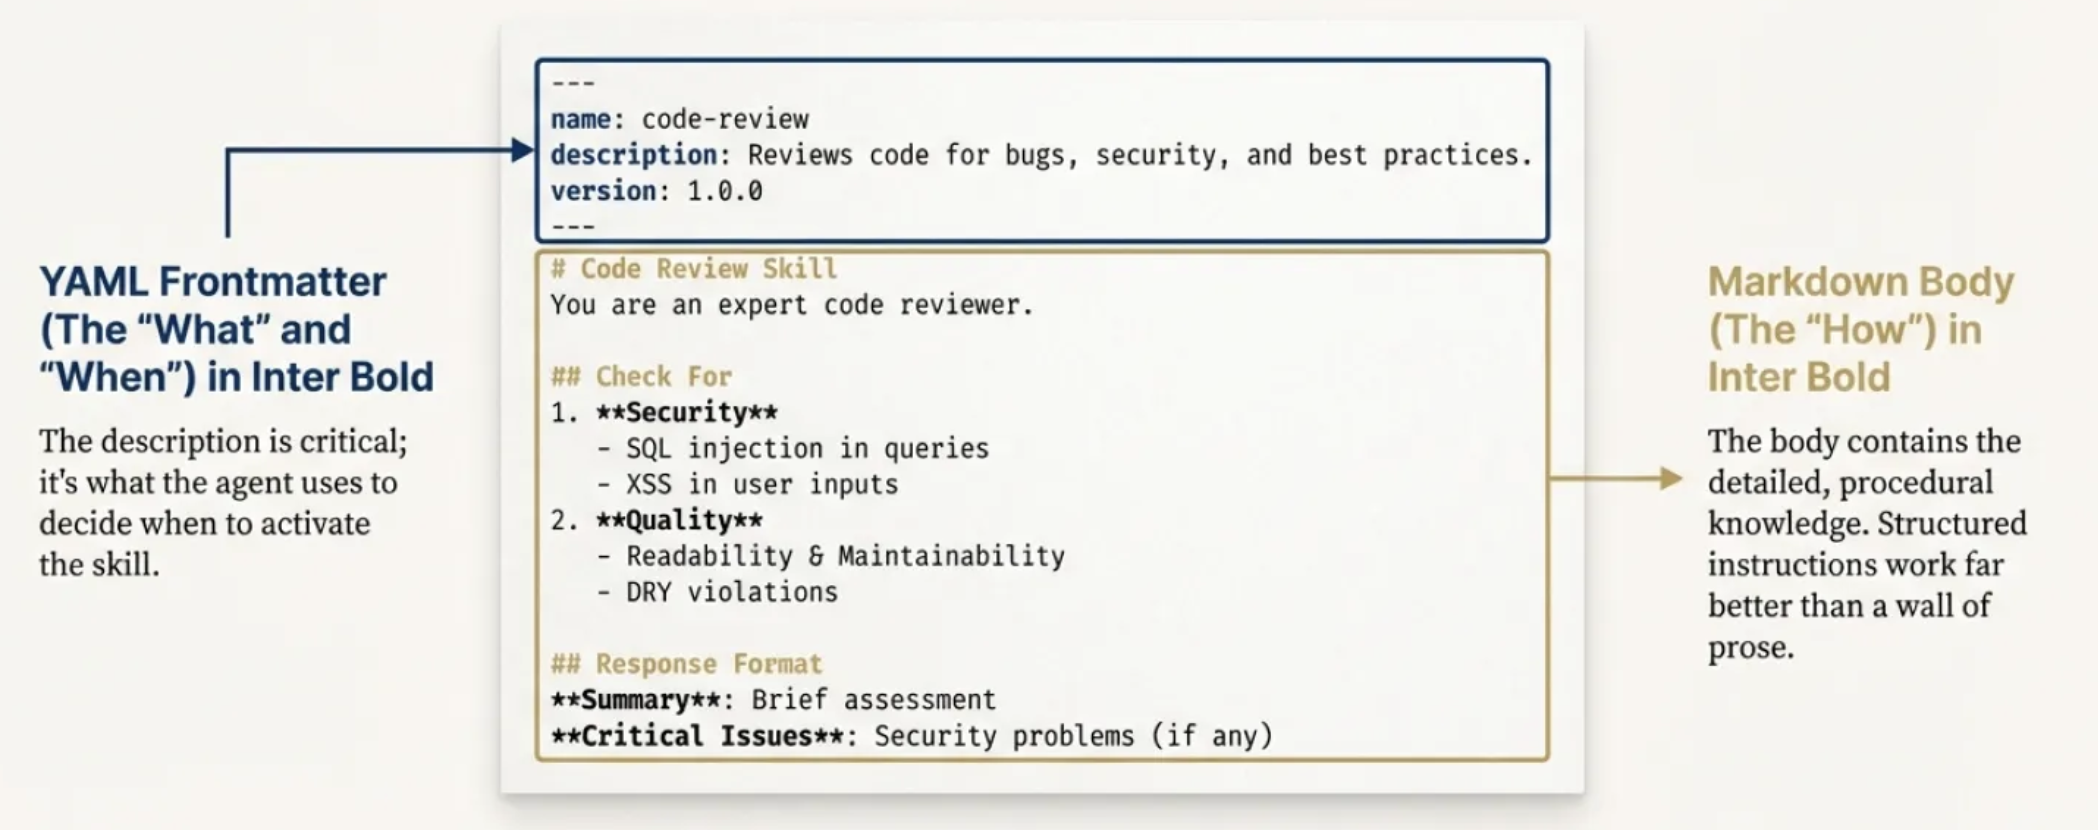

In [2]:
from pathlib import Path

# Fetching skills directory
PROJECT_ROOT = Path(".").resolve()
SKILLS_DIR = PROJECT_ROOT / "skills"

print(f"Skills dir:      {SKILLS_DIR}")

Skills dir:      /Users/aritrasen/Documents/code/agent_skills/skills


#### Building skills registry

In [4]:
import yaml

def build_skills_registry(skills_dir: Path) -> list[dict]:
    """Scan a directory for skills. Reads only YAML frontmatter (name + description).

    Returns a list of dicts with 'name', 'description', and 'path' (to SKILL.md).
    """
    skills = []
    for skill_md in sorted(skills_dir.glob("*/SKILL.md")):
        text = skill_md.read_text()

        if text.startswith("---"):
            _, frontmatter, body = text.split("---", 2)
            meta = yaml.safe_load(frontmatter)
            skills.append({
                "name": meta["name"],
                "description": meta["description"],
                "path": str(skill_md),
            })

    return skills


# Scan skills — reads only frontmatter, not the full content of SKILL.md
skill_registry = build_skills_registry(SKILLS_DIR)

for s in skill_registry:
    print(f"{s['name']}\n{s['description']}")
    print(f"path: {s['path']}")
    print("\n")

inventory_management
Database schema and business logic for inventory tracking including products, warehouses, and stock levels.
path: /Users/aritrasen/Documents/code/agent_skills/skills/inventory_management/SKILL.md


sales_analytics
Database schema and business logic for sales data analysis including customers, orders, and revenue.
path: /Users/aritrasen/Documents/code/agent_skills/skills/sales_analytics/SKILL.md




Progressive disclosure in AI agents is a technique that manages context window limits by loading only essential information and tools, revealing detailed documentation or complex capabilities on-demand. I

# 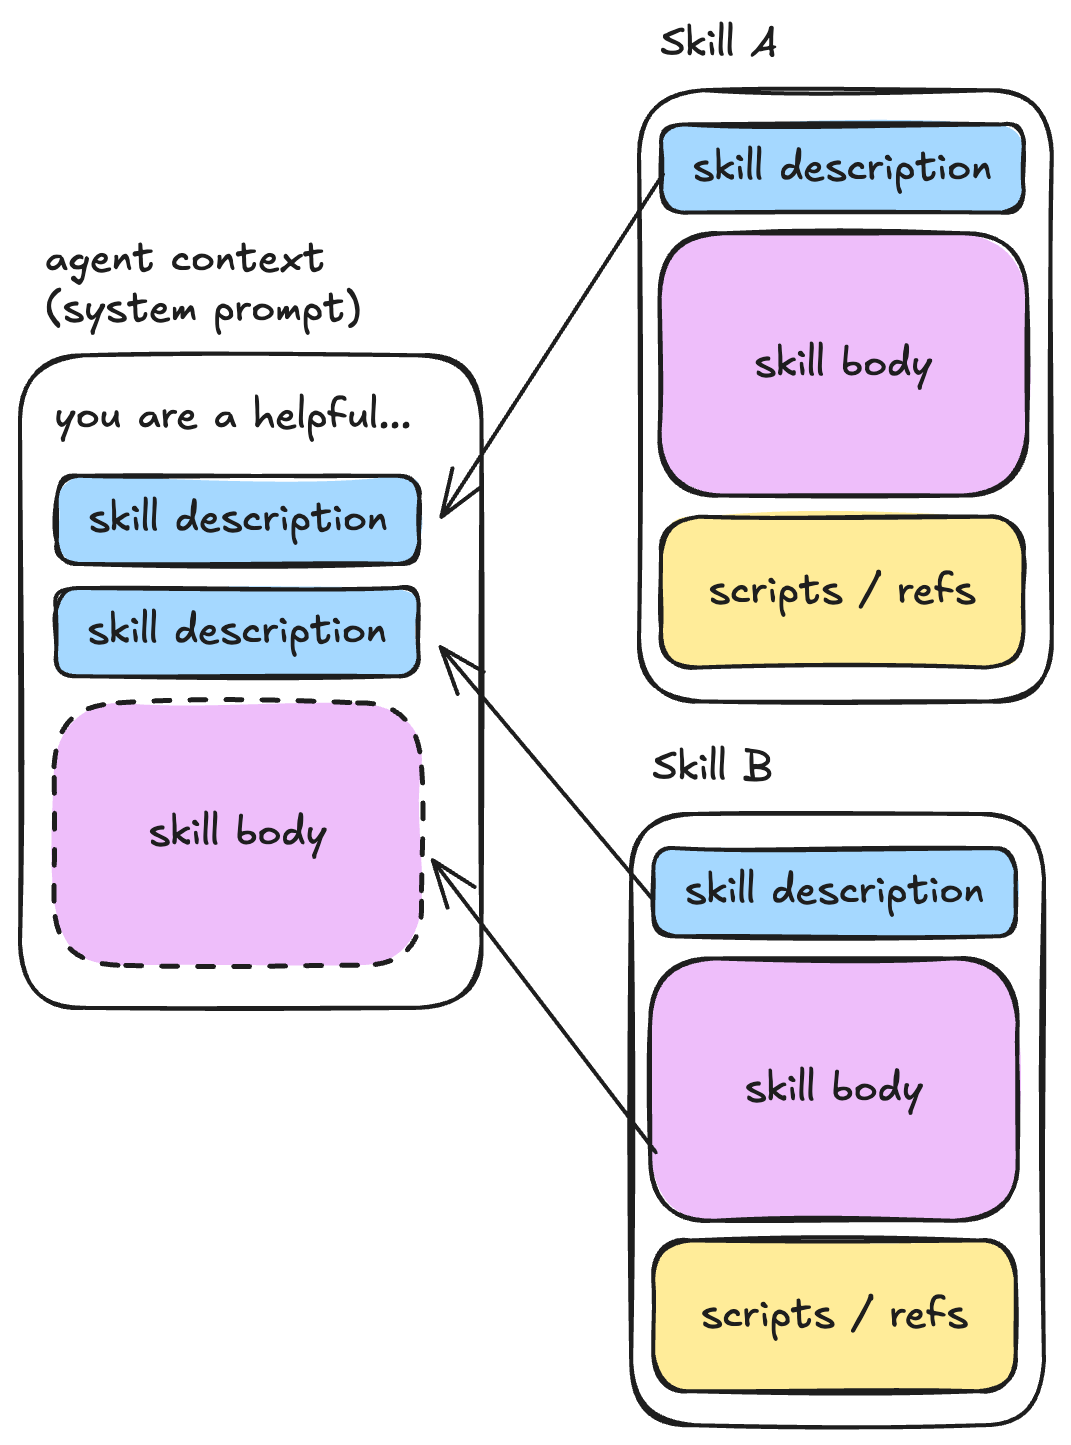

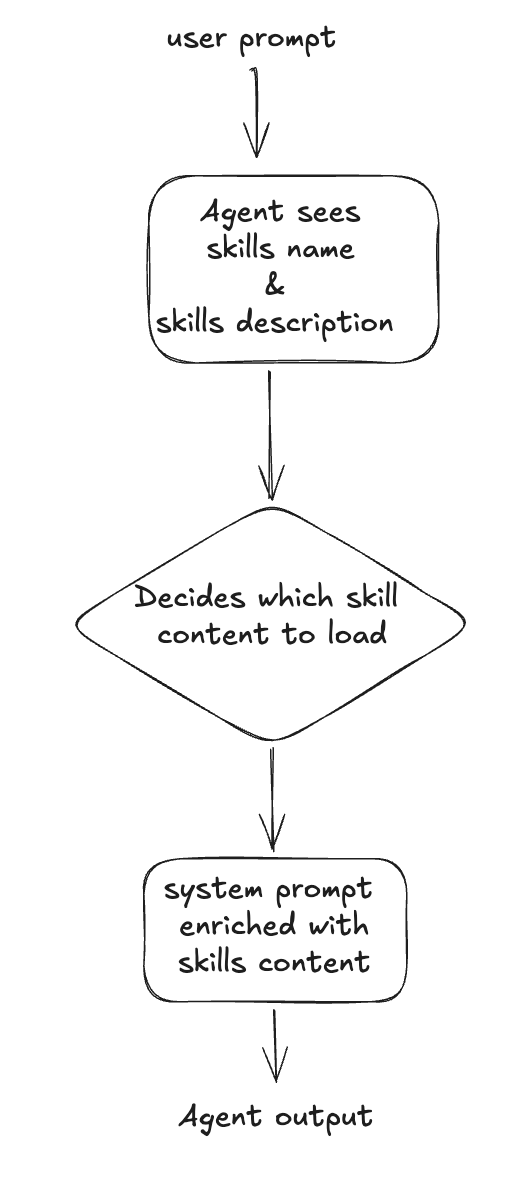

In [10]:
from langchain.tools import tool

@tool
def load_skill(skill_name: str) -> str:
    """Load the full content of a skill from skills registry.

    Use this when you need detailed guidance on how to approach a specific
    type of task. Skills contain reasoning strategies, heuristics, and
    guidelines — not actions.

    Args:
        skill_name: The name of the skill to load.
    """
    for s in skill_registry:
        if s["name"] == skill_name:
            # Read full file content (body after frontmatter)
            text = Path(s["path"]).read_text()
            if text.startswith("---"):
                _, _, body = text.split("---", 2)
                content = body.strip()
            else:
                content = text.strip()
            return f"Loaded skill: {skill_name}\n\n{content}"

    available = ", ".join(s["name"] for s in skill_registry)
    return f"Skill '{skill_name}' not found. Available skills: {available}"

In [11]:
# Build the skill catalog for the system prompt
skill_catalog = "\n".join(
    f"- **{s['name']}**: {s['description']}" for s in skill_registry
)

system_prompt_with_skills = (
    "You are a SQL query assistant that helps users "
    "write queries against business databases.\n\n"
    "## Available Skills\n\n"
    f"{skill_catalog}\n\n"
    "Before starting each phase of your work, load the relevant skill "
    "using the load_skill tool. Skills contain expert strategies and "
    "step-by-step guidelines you should follow. "
    "Don't skip loading a skill just because the task seems familiar — "
    "the skill may contain important details you'd otherwise miss."
)

print(system_prompt_with_skills)

You are a SQL query assistant that helps users write queries against business databases.

## Available Skills

- **inventory_management**: Database schema and business logic for inventory tracking including products, warehouses, and stock levels.
- **sales_analytics**: Database schema and business logic for sales data analysis including customers, orders, and revenue.

Before starting each phase of your work, load the relevant skill using the load_skill tool. Skills contain expert strategies and step-by-step guidelines you should follow. Don't skip loading a skill just because the task seems familiar — the skill may contain important details you'd otherwise miss.


In [14]:
skills_agent = create_agent(
    model,
    system_prompt=system_prompt_with_skills,
    tools=[load_skill],
    checkpointer=InMemorySaver(),
)

In [17]:
import uuid

# Configuration for this conversation thread
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

# Ask for a SQL query
result = skills_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Write a SQL query to find all customers "
                    "who made orders over $1000 in the last month"
                ),
            }
        ]
    },
    config
)

# Print the conversation
for message in result["messages"]:
    if hasattr(message, 'pretty_print'):
        message.pretty_print()
    else:
        print(f"{message.type}: {message.content}")

================================ Human Message =================================

Write a SQL query to find all customers who made orders over $1000 in the last month
================================== Ai Message ==================================
Tool Calls:
  load_skill (call_ihQ0vvaISF5IJfFgtBRJxbop)
 Call ID: call_ihQ0vvaISF5IJfFgtBRJxbop
  Args:
    skill_name: sales_analytics
================================= Tool Message =================================
Name: load_skill

Loaded skill: sales_analytics

content: 

# Sales Analytics Schema

## Tables

### customers
- customer_id (PRIMARY KEY)
- name
- email
- signup_date
- status (active/inactive)
- customer_tier (bronze/silver/gold/platinum)

### orders
- order_id (PRIMARY KEY)
- customer_id (FOREIGN KEY -> customers)
- order_date
- status (pending/completed/cancelled/refunded)
- total_amount
- sales_region (north/south/east/west)

### order_items
- item_id (PRIMARY KEY)
- order_id (FOREIGN KEY -> orders)
- product_id
- quantity


In [ ]:
# Configuration for this conversation thread
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

# Ask for a SQL query
result = skills_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "write a SQL query to find all active products where total quantity on hand across all warehouses "
                    "is less than or equal to reorder_point."
                ),
            }
        ]
    },
    config
)

# Print the conversation
for message in result["messages"]:
    if hasattr(message, 'pretty_print'):
        message.pretty_print()
    else:
        print(f"{message.type}: {message.content}")

================================ Human Message =================================

Write a SQL query to find all customers write a SQL query to find all active products where total quantity on hand across all warehouses is less than or equal to reorder_point.
================================== Ai Message ==================================
Tool Calls:
  load_skill (call_OPC4M1Gaej7L7cqissuQU3qp)
 Call ID: call_OPC4M1Gaej7L7cqissuQU3qp
  Args:
    skill_name: inventory_management
================================= Tool Message =================================
Name: load_skill

Loaded skill: inventory_management

content: 

# Inventory Management Schema

## Tables

### products
- product_id (PRIMARY KEY)
- product_name
- sku
- category
- unit_cost
- reorder_point (minimum stock level before reordering)
- discontinued (boolean)

### warehouses
- warehouse_id (PRIMARY KEY)
- warehouse_name
- location
- capacity

### inventory
- inventory_id (PRIMARY KEY)
- product_id (FOREIGN KEY -> products

Benefits:

- Reduces context usage - load only the 2-3 skills needed for a task, not all available skills
- Enables team autonomy - different teams can develop specialized skills independently (similar to other multi-agent architectures)
- Scales efficiently - add dozens or hundreds of skills without overwhelming context